In [2]:
import micropip
await micropip.install("openpyxl")


In [3]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [5]:
missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [9]:
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 5268


In [10]:
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [11]:
cancelled_orders = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

print("Total cancelled transactions:", len(cancelled_orders))

cancelled_orders.head()

Total cancelled transactions: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [12]:
print("Negative Quantity:", (df["Quantity"] < 0).sum())

print("Zero Quantity:", (df["Quantity"] == 0).sum())

print("Negative Unit Price:", (df["UnitPrice"] < 0).sum())

print("Zero Unit Price:", (df["UnitPrice"] == 0).sum())

Negative Quantity: 10624
Zero Quantity: 0
Negative Unit Price: 2
Zero Unit Price: 2515


In [13]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [14]:
df[df["UnitPrice"] == 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [15]:
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (541909, 8)
Working dataset shape: (541909, 8)


In [16]:
df_clean = df_clean.drop_duplicates()

print("Duplicates remaining:", df_clean.duplicated().sum())
print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicates remaining: 0
Dataset shape after removing duplicates: (536641, 8)


In [17]:
df_cancelled = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

print("Cancelled transactions:", df_cancelled.shape[0])

Cancelled transactions: 9251


In [18]:
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

print("Main dataset shape after removing cancellations:", df_clean.shape)

Main dataset shape after removing cancellations: (527390, 8)


In [19]:
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

print("Dataset shape after removing invalid records:", df_clean.shape)

Dataset shape after removing invalid records: (524878, 8)


In [20]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
print(
    "Missing Customer IDs:",
    df_clean["CustomerID"].isnull().sum()
)

Missing Customer IDs: 132186


In [22]:
print("Final cleaned dataset shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nData Types:")
print(df_clean.dtypes)

df_clean.head()

Final cleaned dataset shape: (524878, 9)

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [27]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year

df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()

df_clean["Day"] = df_clean["InvoiceDate"].dt.day

df_clean["Day_of_Week"] = df_clean["InvoiceDate"].dt.day_name()

df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Day,Day_of_Week,Hour,Month_Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12


In [24]:
print(df_clean.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week', 'Hour']


In [25]:
df_clean["Month_Year"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

df_clean[["InvoiceDate", "Year", "Month", "Month_Name", "Month_Year"]].head()

,InvoiceDate,Year,Month,Month_Name,Month_Year
0,2010-12-01 08:26:00,2010,12,December,2010-12
1,2010-12-01 08:26:00,2010,12,December,2010-12
2,2010-12-01 08:26:00,2010,12,December,2010-12
3,2010-12-01 08:26:00,2010,12,December,2010-12
4,2010-12-01 08:26:00,2010,12,December,2010-12


In [28]:
df_customer = df_clean.dropna(subset=["CustomerID"]).copy()

print("Customer analysis dataset shape:", df_customer.shape)

print("Missing Customer IDs:", df_customer["CustomerID"].isnull().sum())

Customer analysis dataset shape: (392692, 16)
Missing Customer IDs: 0


In [29]:
total_revenue = df_clean["Revenue"].sum()

total_orders = df_clean["InvoiceNo"].nunique()

total_products_sold = df_clean["Quantity"].sum()

unique_customers = df_customer["CustomerID"].nunique()

average_order_value = (
    df_clean.groupby("InvoiceNo")["Revenue"].sum().mean()
)

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Products Sold: {total_products_sold:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Total Products Sold: 5,572,420
Unique Customers: 4,338
Average Order Value: £533.17


## Monthly Revenue Trend 📈

In [30]:
monthly_revenue = (
    df_clean.groupby("Month_Year")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,Month_Year,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


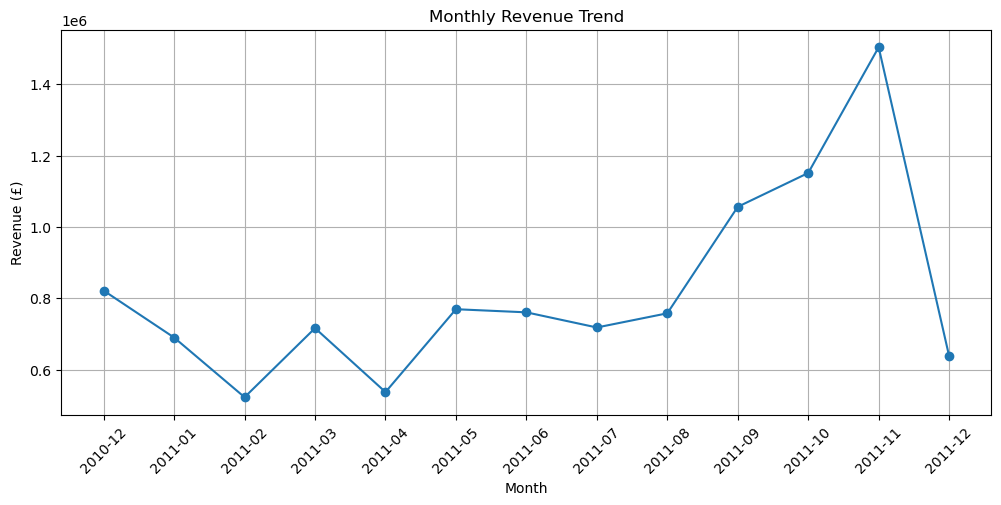

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month_Year"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Analyze Revenue by Country 🌍

In [32]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(10)

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


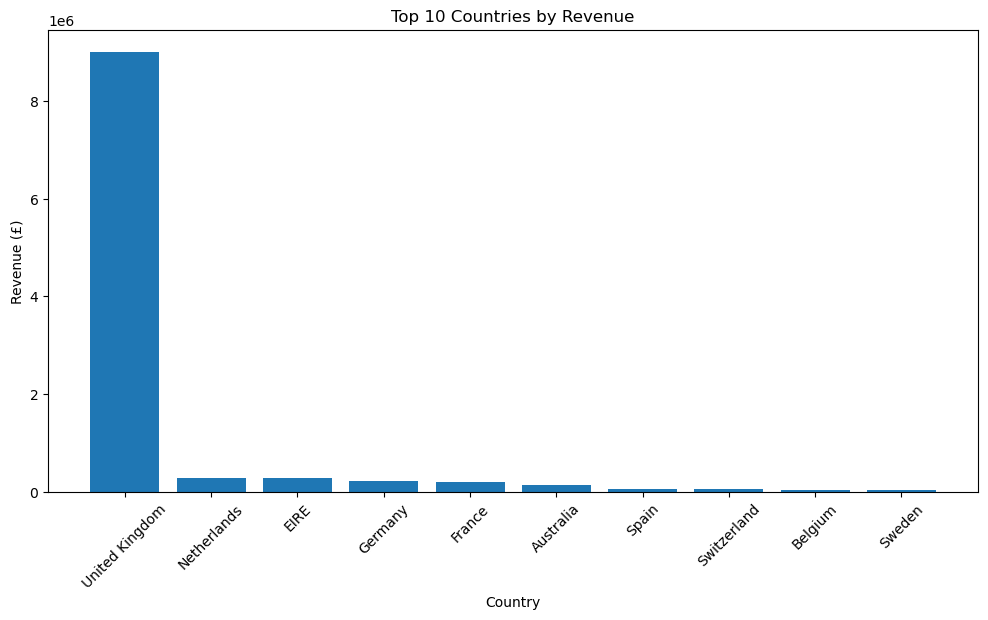

In [33]:
import matplotlib.pyplot as plt

top_10_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_countries["Country"],
    top_10_countries["Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

In [34]:
revenue_excluding_uk = (
    df_clean[df_clean["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

revenue_excluding_uk

,Country,Revenue
0,Netherlands,285446.34
1,EIRE,283140.52
2,Germany,228678.40
3,France,209625.37
4,Australia,138453.81
5,Spain,61558.56
6,Switzerland,57067.60
7,Belgium,41196.34
8,Sweden,38367.83
9,Japan,37416.37


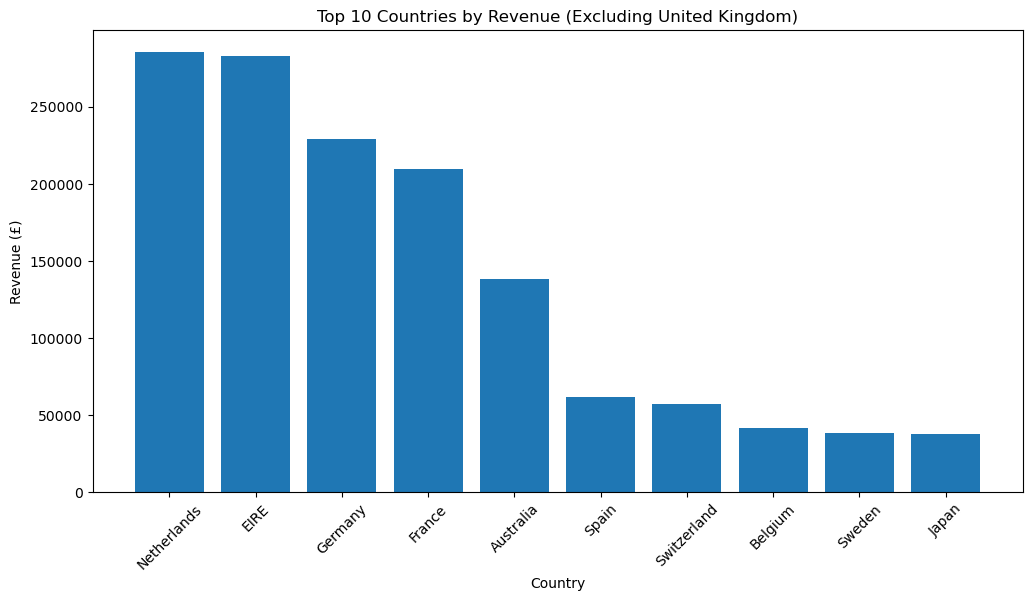

In [35]:
plt.figure(figsize=(12, 6))

plt.bar(
    revenue_excluding_uk["Country"],
    revenue_excluding_uk["Revenue"]
)

plt.title("Top 10 Countries by Revenue (Excluding United Kingdom)")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

# Top 10 Products by Revenue 💰

In [36]:
top_products_revenue = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_revenue

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174156.54
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
4,PARTY BUNTING,99445.23
5,JUMBO BAG RED RETROSPOT,94159.81
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POSTAGE,78101.88
8,Manual,77752.82
9,RABBIT NIGHT LIGHT,66870.03


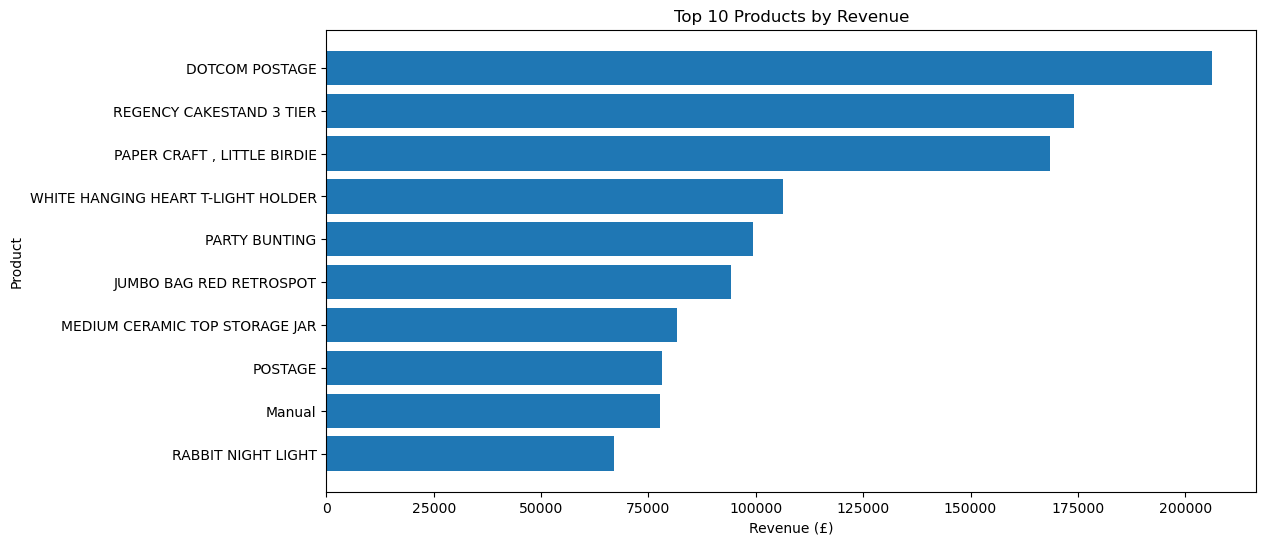

In [37]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_products_revenue["Description"],
    top_products_revenue["Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

# Top 10 Products by Quantity Sold 📦

In [38]:
top_products_quantity = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_quantity

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48371
4,WHITE HANGING HEART T-LIGHT HOLDER,37872
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


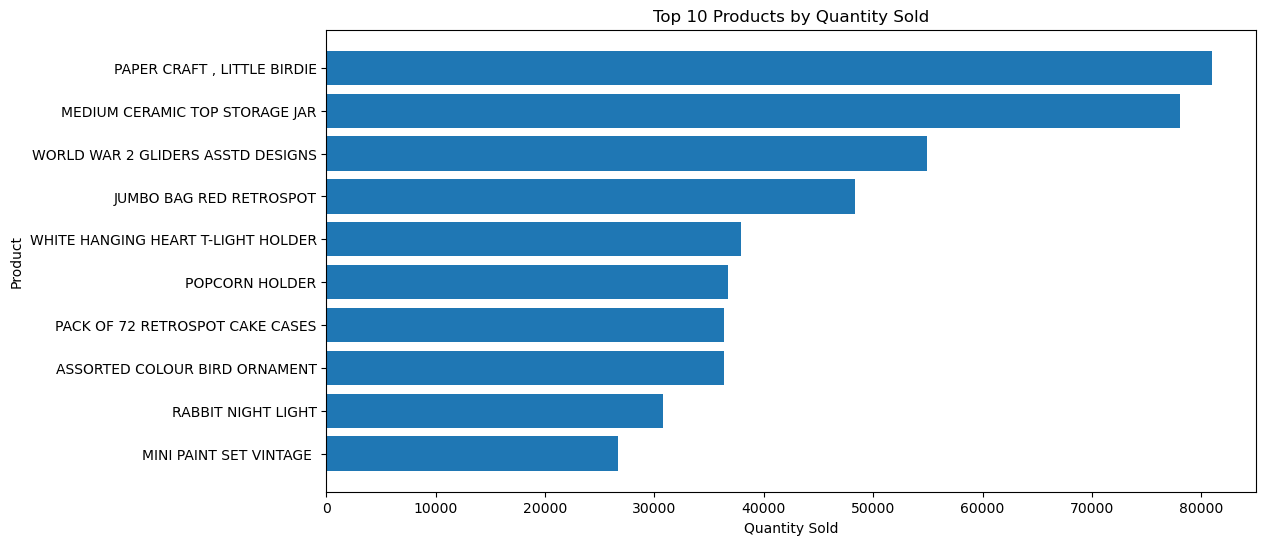

In [39]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_products_quantity["Description"],
    top_products_quantity["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

# Customer Analysis 👥

## Top 10 Customers by Revenue

In [40]:
top_customers = (
    df_customer.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


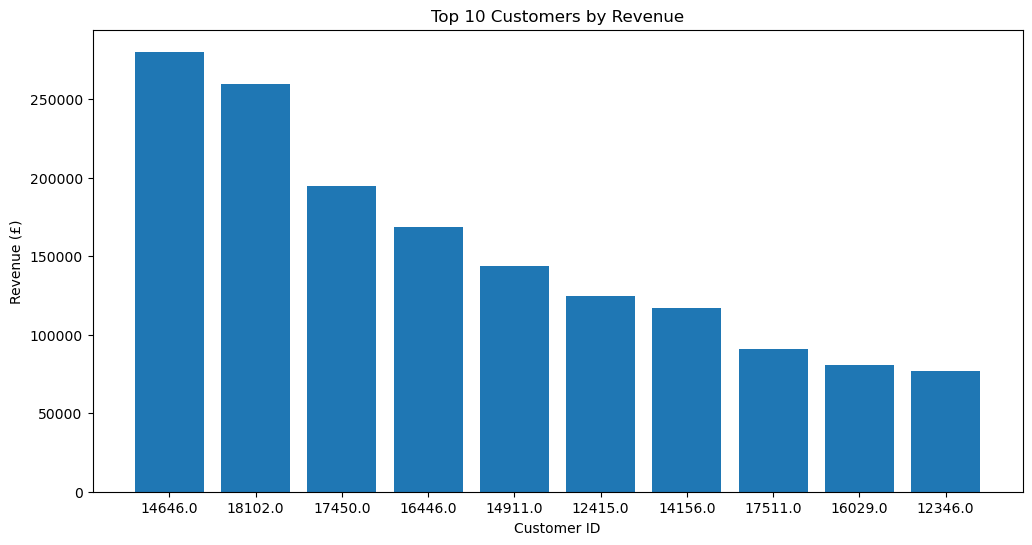

In [41]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")

plt.show()

## Customer Purchase Frequency

In [42]:
customer_frequency = (
    df_customer.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

customer_frequency.columns = ["CustomerID", "Number_of_Orders"]

customer_frequency.head(10)

,CustomerID,Number_of_Orders
0,12748.0,209
1,14911.0,201
2,17841.0,124
3,13089.0,97
4,14606.0,93
5,15311.0,91
6,12971.0,86
7,14646.0,73
8,16029.0,63
9,13408.0,62


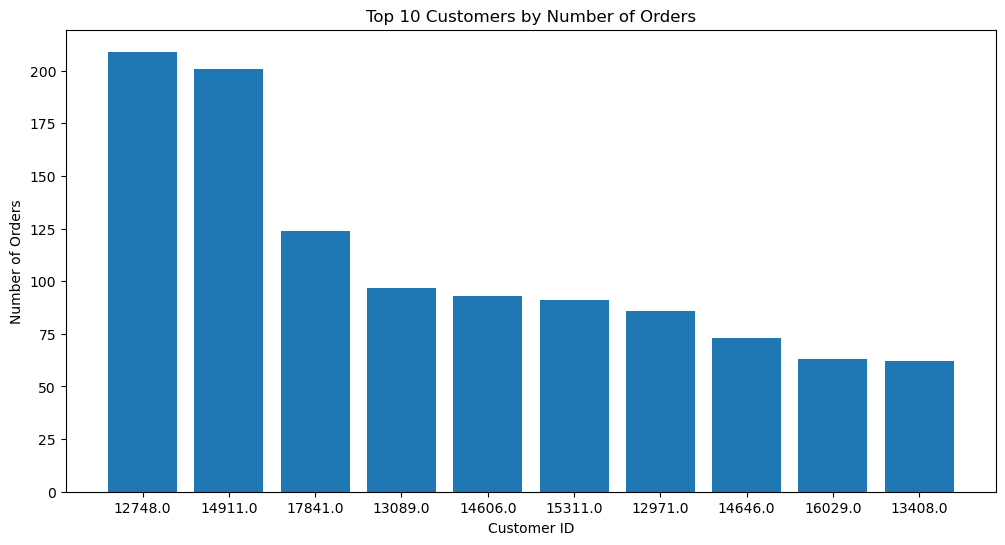

In [43]:
top_frequency = customer_frequency.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_frequency["CustomerID"].astype(str),
    top_frequency["Number_of_Orders"]
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.show()

# Repeat vs One-Time Customers

In [44]:
customer_order_counts = (
    df_customer.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

one_time_customers = (customer_order_counts == 1).sum()
repeat_customers = (customer_order_counts > 1).sum()

print(f"One-Time Customers: {one_time_customers:,}")
print(f"Repeat Customers: {repeat_customers:,}")

repeat_rate = (
    repeat_customers / len(customer_order_counts)
) * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

One-Time Customers: 1,493
Repeat Customers: 2,845
Repeat Customer Rate: 65.58%


# RFM Customer Segmentation

In [45]:
# Find the latest purchase date in the dataset
snapshot_date = df_customer["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM metrics for each customer
rfm = df_customer.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

# Rename columns
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [46]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


# RFM Scores ⭐

In [47]:
# Recency Score
# Lower recency is better, so we reverse the scoring
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# Frequency Score
# Higher frequency is better
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary Score
# Higher spending is better
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


## Combined RFM Score

In [48]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112
5,12352.0,36,8,2506.04,3,5,5,355
6,12353.0,204,1,89.00,1,1,1,111
7,12354.0,232,1,1079.40,1,1,4,114
8,12355.0,214,1,459.40,1,1,2,112
9,12356.0,23,3,2811.43,4,3,5,435


# Customer Segments 🎯
Instead of using only the exact combined score, we'll use the individual R, F, and M scores.

In [49]:
def customer_segment(row):
    
    if (
        row["R_Score"] >= 4
        and row["F_Score"] >= 4
        and row["M_Score"] >= 4
    ):
        return "Champions"
    
    elif (
        row["R_Score"] >= 3
        and row["F_Score"] >= 4
    ):
        return "Loyal Customers"
    
    elif (
        row["R_Score"] >= 4
        and row["F_Score"] >= 2
    ):
        return "Potential Loyalists"
    
    elif (
        row["R_Score"] <= 2
        and row["F_Score"] >= 3
        and row["M_Score"] >= 3
    ):
        return "At Risk"
    
    elif row["R_Score"] <= 2:
        return "Lost Customers"
    
    else:
        return "Others"


rfm["Segment"] = rfm.apply(customer_segment, axis=1)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Lost Customers
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,Others
4,12350.0,310,1,334.40,1,1,2,112,Lost Customers
5,12352.0,36,8,2506.04,3,5,5,355,Loyal Customers
6,12353.0,204,1,89.00,1,1,1,111,Lost Customers
7,12354.0,232,1,1079.40,1,1,4,114,Lost Customers
8,12355.0,214,1,459.40,1,1,2,112,Lost Customers
9,12356.0,23,3,2811.43,4,3,5,435,Potential Loyalists


## Count Customers in Each Segment

In [50]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Number_of_Customers"]

segment_summary

,Segment,Number_of_Customers
0,Lost Customers,1255
1,Champions,957
2,Others,678
3,Loyal Customers,503
4,Potential Loyalists,492
5,At Risk,453


## Visualize Customer Segments

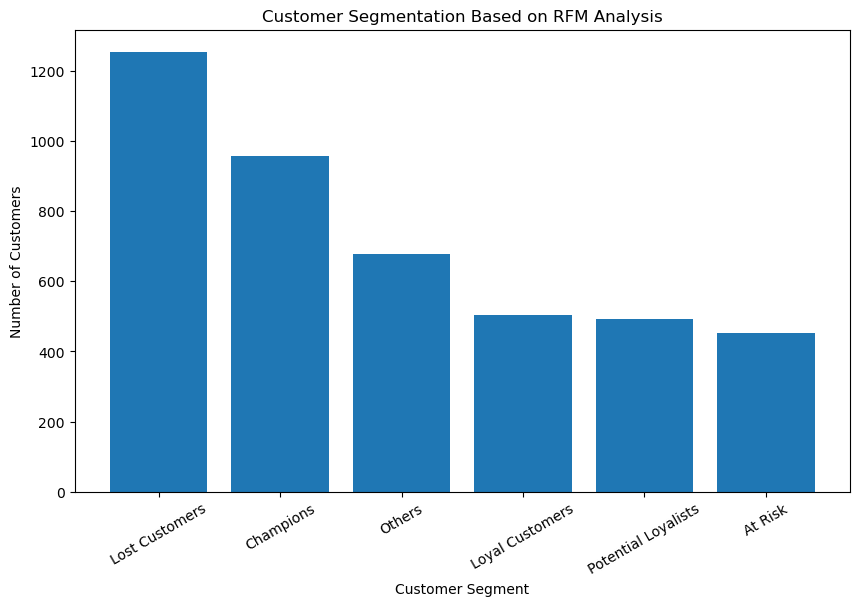

In [51]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Number_of_Customers"]
)

plt.title("Customer Segmentation Based on RFM Analysis")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

# Analyze Revenue by Customer Segment
Now we need to answer an important business question:

Which customer segment actually generates the most revenue?

In [52]:
segment_revenue = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

segment_revenue

,Segment,Customers,Total_Revenue,Average_Revenue
1,Champions,957,5791640.740,6051.871202
3,Loyal Customers,503,895651.561,1780.619406
0,At Risk,453,739477.551,1632.400775
2,Lost Customers,1255,576897.112,459.678974
5,Potential Loyalists,492,506813.630,1030.109004
4,Others,678,376728.300,555.646460


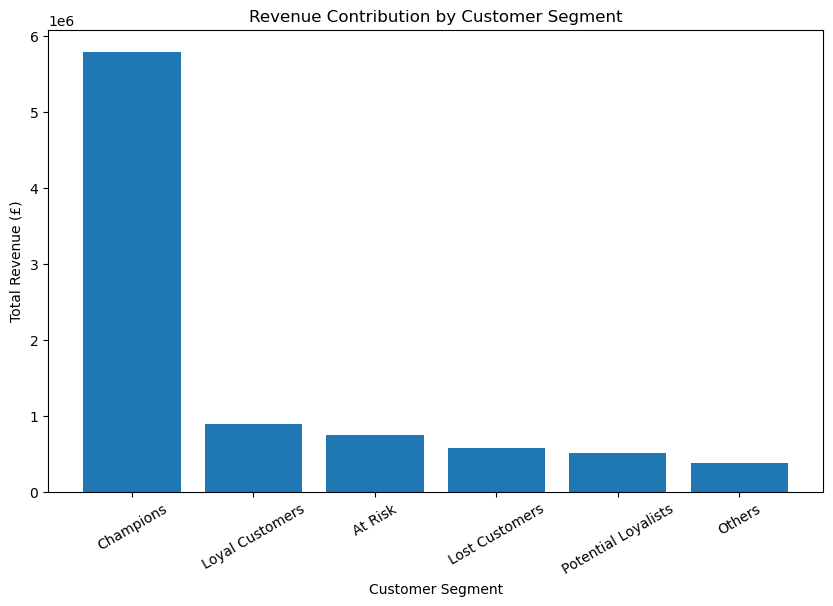

In [53]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Total_Revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=30)

plt.show()

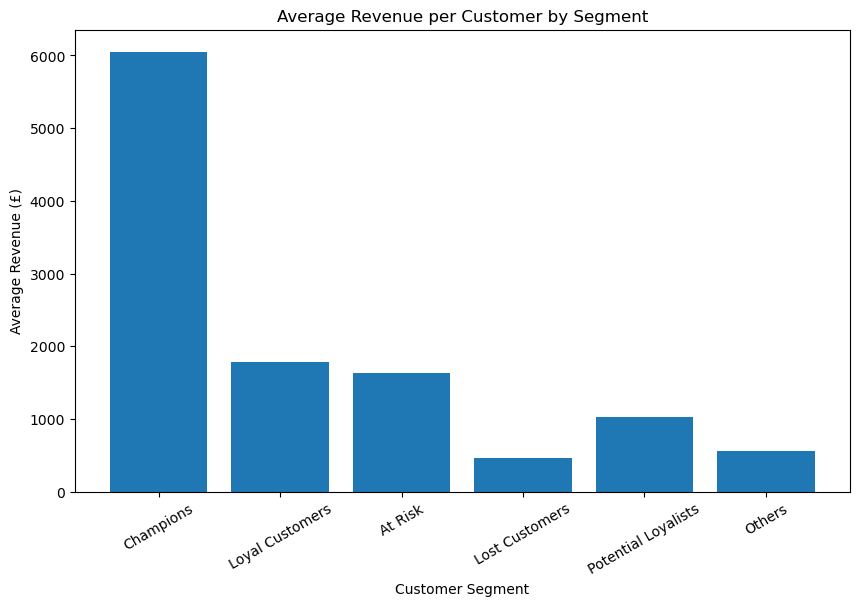

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue["Segment"],
    segment_revenue["Average_Revenue"]
)

plt.title("Average Revenue per Customer by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Revenue (£)")
plt.xticks(rotation=30)

plt.show()

# Dashboard Summary Data

In [56]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [57]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]


In [58]:
# Create key performance indicators

total_revenue = df["Revenue"].sum()

total_orders = df["InvoiceNo"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["Description"].nunique()

print("📊 KEY PERFORMANCE INDICATORS")
print("-" * 35)
print(f"💰 Total Revenue: £{total_revenue:,.2f}")
print(f"🧾 Total Orders: {total_orders:,}")
print(f"👥 Total Customers: {total_customers:,}")
print(f"📦 Total Products: {total_products:,}")


📊 KEY PERFORMANCE INDICATORS
-----------------------------------
💰 Total Revenue: £9,747,747.93
🧾 Total Orders: 25,900
👥 Total Customers: 4,372
📦 Total Products: 4,223


# Monthly Sales Summary


In [59]:
# Monthly sales summary

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

monthly_sales

,Month,Total_Revenue,Total_Orders,Total_Quantity
0,2010-12,748957.020,2025,342228
1,2011-01,560000.260,1476,308966
2,2011-02,498062.650,1393,277989
3,2011-03,683267.080,1983,351872
4,2011-04,493207.121,1744,289098
5,2011-05,723333.510,2162,380391
6,2011-06,691123.120,2012,341623
7,2011-07,681300.111,1927,391116
8,2011-08,682680.510,1737,406199
9,2011-09,1019687.622,2327,549817


# Country-wise Sales Summary 🌍

In [60]:
# Country-wise sales summary

country_sales = (
    df.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

country_sales.head(10)

,Country,Total_Revenue,Total_Orders,Total_Quantity,Total_Customers
36,United Kingdom,8187806.364,23494,4263829,3950
24,Netherlands,284661.540,101,200128,9
10,EIRE,263276.820,360,142637,3
14,Germany,221698.210,603,117448,95
13,France,197403.900,461,110480,87
0,Australia,137077.270,69,83653,9
33,Switzerland,56385.350,74,30325,21
31,Spain,54774.580,105,26824,31
3,Belgium,40910.960,119,23152,25
32,Sweden,36595.910,46,35637,8


# Top Products Summary

In [61]:
# Top products summary

top_products = (
    df.groupby("Description")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Total_Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

top_products.head(10)

,Description,Total_Revenue,Total_Quantity,Total_Orders
1098,DOTCOM POSTAGE,206245.48,707,709
2915,REGENCY CAKESTAND 3 TIER,164762.19,13033,2169
3918,WHITE HANGING HEART T-LIGHT HOLDER,99668.47,35317,2302
2471,PARTY BUNTING,98302.98,18022,1706
1866,JUMBO BAG RED RETROSPOT,92356.03,47363,2135
2803,RABBIT NIGHT LIGHT,66756.59,30680,1009
2753,POSTAGE,66230.64,3003,1250
2439,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94,18902,1170
244,ASSORTED COLOUR BIRD ORNAMENT,58959.73,36381,1467
773,CHILLI LIGHTS,53768.06,10229,669


# RFM Customer Data for Export

In [62]:
# Check RFM customer segmentation data

rfm_export = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "Segment"
    ]
]

rfm_export.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Lost Customers
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,Others
4,12350.0,310,1,334.40,1,1,2,112,Lost Customers
5,12352.0,36,8,2506.04,3,5,5,355,Loyal Customers
6,12353.0,204,1,89.00,1,1,1,111,Lost Customers
7,12354.0,232,1,1079.40,1,1,4,114,Lost Customers
8,12355.0,214,1,459.40,1,1,2,112,Lost Customers
9,12356.0,23,3,2811.43,4,3,5,435,Potential Loyalists


In [63]:
rfm_export.to_csv("rfm_customer_segmentation.csv", index=False)

print("RFM customer segmentation file created successfully!")
print(f"Total Customers: {len(rfm_export):,}")

RFM customer segmentation file created successfully!
Total Customers: 4,338
